In [10]:
#0. 最初要改变的变量
Topology_Version = 'gridx'
P=18
N=36

# 数据处理
这一章节，我们要开始数据后处理，就是上面数据导出后，我们需要进行同轨异轨的一个分析验证


In [2]:
from pathlib import Path
import re
import pandas as pd


def read_pair_csv(
    csv_path,
    *,
    time_col="time",
    station_a_col="station_a",
    station_b_col="station_b",
    path_col="path",
    ensure_int=True,
):
    """
    读取一份 station 对的最短路径 CSV。

    支持两种情况：
    1) CSV 本身包含 station_a / station_b 列
    2) CSV 没有这两列时，从文件名中提取（如 region1--station12-region2--station19.csv）
    """
    path = Path(csv_path)
    df = pd.read_csv(path)

    # 缺列校验
    if time_col not in df.columns:
        raise ValueError(f"CSV 缺少列: {time_col} -> {path}")

    # 文件名兜底解析 station 对
    if station_a_col not in df.columns or station_b_col not in df.columns:
        m = re.match(r".*station(\d+)-[^-]*-station(\d+)", path.stem)
        if not m:
            raise ValueError(
                f"CSV 缺少 {station_a_col}/{station_b_col}，且文件名无法解析: {path.name}"
            )
        df[station_a_col] = int(m.group(1))
        df[station_b_col] = int(m.group(2))

    # 可选字段保证存在
    if path_col not in df.columns:
        df[path_col] = ""

    if ensure_int:
        df[time_col] = pd.to_numeric(df[time_col], errors="coerce").astype("Int64")
        df[station_a_col] = pd.to_numeric(df[station_a_col], errors="coerce").astype("Int64")
        df[station_b_col] = pd.to_numeric(df[station_b_col], errors="coerce").astype("Int64")

    # 简单标准列
    return (
        df
        .loc[:, [time_col, station_a_col, station_b_col, path_col] + [
            c for c in df.columns
            if c not in {time_col, station_a_col, station_b_col, path_col}
        ]]
        .copy()
    )


In [3]:


DATA_DIR = Path(r"D:\paper3")
BASEDIR =  DATA_DIR / "data"

Topology_DIR = 'topology_design'

In [4]:
FIGURE_DIR = BASEDIR / Topology_DIR / Topology_Version/"path"

data_DIR = Path(FIGURE_DIR) / "region_pairs_0_100"   # 你导出的原始 csv 目录


In [5]:

# data_DIR = Path(FIGURE_DIR) / "region1_to_region2_0_100"   # 你导出的原始 csv 目录

df = read_pair_csv(data_DIR / "region1--station0-region2--station19.csv")

In [6]:
df

,time,station_a,station_b,path,best_s,best_d,path_indexed
0,0,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
1,1,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
2,2,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
3,3,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
4,4,0,19,86->85->120->119->154->153->188->187->222->221...,86,362,"1:86,2:85,3:120,4:119,5:154,6:153,7:188,8:187,..."
...,...,...,...,...,...,...,...
96,96,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."
97,97,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."
98,98,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."
99,99,0,19,85->120->119->154->153->188->187->222->221->25...,85,361,"1:85,2:120,3:119,4:154,5:153,6:188,7:187,8:222..."


In [ ]:
dfpath = df["path"]

In [11]:
# ========== 路径 → intra/inter 链路分类 ==========
# 星座参数
# P = 18
# N = 36

import src.model.get_intra_inter_link as get_intra_inter_link
# def parse_path_links(path_str, N=36):
#     """
#     输入: '86->85->120->119->...'
#     输出: (intra_links, inter_links)
#         intra_links: [(86,85), ...]   同轨链路（orbit 相同）
#         inter_links: [(85,120), ...]  异轨链路（orbit 不同）
#     """
#     if not path_str or path_str == "":
#         return [], []
#
#     nodes = [int(x) for x in path_str.split("->")]
#     intra_links = []
#     inter_links = []
#
#     for i in range(len(nodes) - 1):
#         src, dst = nodes[i], nodes[i + 1]
#         src_orbit = src // N
#         dst_orbit = dst // N
#
#         if src_orbit == dst_orbit:
#             intra_links.append((src, dst))
#         else:
#             inter_links.append((src, dst))
#
#     return intra_links, inter_links


# ========== 对 dfpath 整列批量处理 ==========
# 假设 dfpath 是 DataFrame 的 "path" 列，即 df["path"]

all_intra = []
all_inter = []

for idx, path_str in enumerate(df["path"]):
    intra, inter = get_intra_inter_link.parse_path_links(path_str, N=N)
    all_intra.append(intra)
    all_inter.append(inter)

# 写回 DataFrame
df["intra_links"] = all_intra    # 每行是 [(src,dst), ...] 的 list
df["inter_links"] = all_inter

# 同时统计跳数
df["intra_hops"] = df["intra_links"].apply(len)
df["inter_hops"] = df["inter_links"].apply(len)
df["total_hops"] = df["intra_hops"] + df["inter_hops"]


In [12]:
df["intra_hops"]


0      6
1      6
2      6
3      6
4      6
      ..
96     6
97     6
98     6
99     6
100    6
Name: intra_hops, Length: 101, dtype: int64

In [13]:
def plot_intra_inter_hops_over_time(
    df,
    *,
    time_col="time",
    intra_col="intra_hops",
    inter_col="inter_hops",
    figsize=(10, 4),
    title="Intra-orbit vs Inter-orbit hops over time",
    show=True,
    save=None,
    save_dir="figs",
    basename="intra_inter_hops",
    formats=("png", "pdf"),
    dpi=300,
    return_handles=True,
):
    import matplotlib as mpl
    import matplotlib.pyplot as plt

    base_rc = {
        "font.family": "Times New Roman",
        "font.size": 14,
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.2,
    }

    plt.ion()
    with mpl.rc_context(base_rc):
        fig, ax = plt.subplots(figsize=figsize)

        t = df[time_col]

        ax.plot(t, df[intra_col], marker='o', markersize=3,
                linewidth=1.5, color='#2196F3', label='Intra-orbit hops')
        ax.plot(t, df[inter_col], marker='s', markersize=3,
                linewidth=1.5, color='#F44336', label='Inter-orbit hops')
        ax.plot(t, df[intra_col] + df[inter_col], marker='^', markersize=3,
                linewidth=1.2, color='#888888', linestyle='--', label='Total hops')

        ax.set_xlabel("Time Step")
        ax.set_ylabel("Hops")
        ax.set_title(title)
        ax.legend(framealpha=0.9)
        ax.grid(alpha=0.3, linestyle="--")
        plt.tight_layout()

        if show:
            plt.show(block=False)
            try:
                plt.pause(0.01)
            except Exception:
                pass

    if save:
        from pathlib import Path
        targets = []
        if save is True:
            outdir = Path(save_dir); outdir.mkdir(parents=True, exist_ok=True)
            for ext in formats:
                targets.append(outdir / f"{basename}.{ext.lstrip('.')}")
        else:
            targets = [save] if isinstance(save, (str, Path)) else list(save)
        for p in targets:
            p = Path(p)
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=dpi, bbox_inches="tight")

    return (fig, ax, df) if return_handles else None


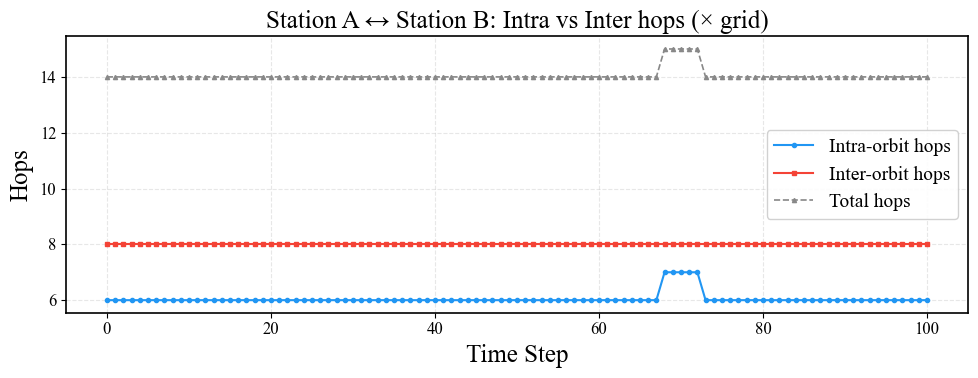

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Station A ↔ Station B: Intra vs Inter hops (× grid)'}, xlabel='Time Step', ylabel='Hops'>,
      time  station_a  station_b  \
 0       0          0         19   
 1       1          0         19   
 2       2          0         19   
 3       3          0         19   
 4       4          0         19   
 ..    ...        ...        ...   
 96     96          0         19   
 97     97          0         19   
 98     98          0         19   
 99     99          0         19   
 100   100          0         19   
 
                                                   path  best_s  best_d  \
 0    86->85->120->119->154->153->188->187->222->221...      86     362   
 1    86->85->120->119->154->153->188->187->222->221...      86     362   
 2    86->85->120->119->154->153->188->187->222->221...      86     362   
 3    86->85->120->119->154->153->188->187->222->221...      86     362   
 4    86->85->120->119->154->153->188

In [14]:
plot_intra_inter_hops_over_time(
    df,
    title="Station A ↔ Station B: Intra vs Inter hops (× grid)",
)


In [17]:
def plot_route_reliability_over_time(
    df,
    *,
    p_intra=0.999,
    p_inter=0.99,
    intra_col="intra_hops",
    inter_col="inter_hops",
    time_col="time",
    figsize=(10, 4),
    title=None,
    show=True,
    save=None,
    save_dir="figs",
    basename="route_reliability",
    formats=("png", "pdf"),
    dpi=300,
    return_handles=True,
):
    """
    路由端到端稳定概率 = p_intra^(intra_hops) × p_inter^(inter_hops)
    """
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import numpy as np

    reliability = (p_intra ** df[intra_col]) * (p_inter ** df[inter_col])

    # 写回 DataFrame 方便后续使用
    col_name = f"reliability_pi{p_intra}_pe{p_inter}"
    df[col_name] = reliability

    base_rc = {
        "font.family": "Times New Roman",
        "font.size": 14,
        "axes.labelsize": 18,
        "axes.titlesize": 18,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "axes.linewidth": 1.2,
    }

    plt.ion()
    with mpl.rc_context(base_rc):
        fig, ax = plt.subplots(figsize=figsize)

        ax.plot(df[time_col], reliability * 100,
                marker='o', markersize=3, linewidth=1.5, color='#4CAF50')

        ax.set_xlabel("Time Step")
        ax.set_ylabel("Route Reliability (%)")
        ax.set_ylim(bottom=max(0, (reliability.min() * 100) - 2),
                     top=min(100, (reliability.max() * 100) + 1))

        if title is None:
            title = (f"End-to-End Route Reliability "
                     f"($p_{{intra}}$={p_intra}, $p_{{inter}}$={p_inter})")
        ax.set_title(title)
        ax.grid(alpha=0.3, linestyle="--")
        plt.tight_layout()

        if show:
            plt.show(block=False)
            try:
                plt.pause(0.01)
            except Exception:
                pass

    if save:
        from pathlib import Path
        targets = []
        if save is True:
            outdir = Path(save_dir); outdir.mkdir(parents=True, exist_ok=True)
            for ext in formats:
                targets.append(outdir / f"{basename}.{ext.lstrip('.')}")
        else:
            targets = [save] if isinstance(save, (str, Path)) else list(save)
        for p in targets:
            p = Path(p)
            p.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(p, dpi=dpi, bbox_inches="tight")

    return (fig, ax, df) if return_handles else None


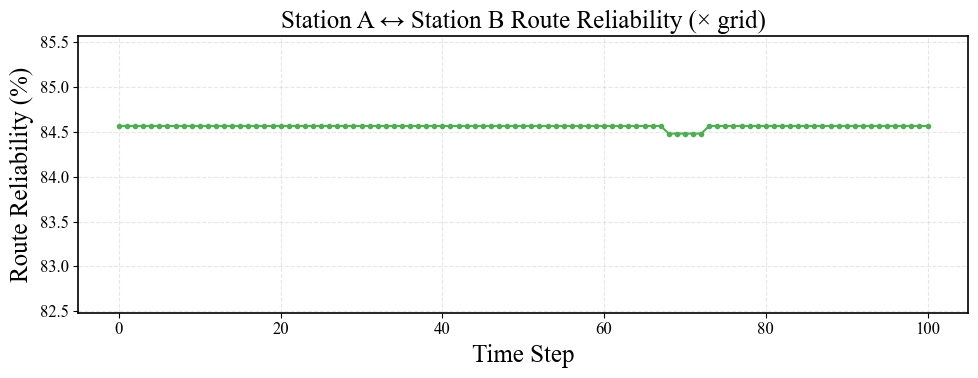

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Station A ↔ Station B Route Reliability (× grid)'}, xlabel='Time Step', ylabel='Route Reliability (%)'>,
      time  station_a  station_b  \
 0       0          0         19   
 1       1          0         19   
 2       2          0         19   
 3       3          0         19   
 4       4          0         19   
 ..    ...        ...        ...   
 96     96          0         19   
 97     97          0         19   
 98     98          0         19   
 99     99          0         19   
 100   100          0         19   
 
                                                   path  best_s  best_d  \
 0    86->85->120->119->154->153->188->187->222->221...      86     362   
 1    86->85->120->119->154->153->188->187->222->221...      86     362   
 2    86->85->120->119->154->153->188->187->222->221...      86     362   
 3    86->85->120->119->154->153->188->187->222->221...      86     362   
 4    86->85->120->119-

In [18]:
plot_route_reliability_over_time(
    df,
    p_intra=0.999,
    p_inter=0.98,
    title="Station A ↔ Station B Route Reliability (× grid)",
)
